In [1]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('train.csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [5]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

In [6]:
df['Order Date'].head()

,Order Date
0,2017-11-08
1,2017-11-08
2,2017-06-12
3,2016-10-11
4,2016-10-11


In [7]:
total_sales = df['Sales'].sum()
total_orders = df.shape[0]

print("Total Sales:", total_sales)
print("Total Orders:", total_orders)

Total Sales: 2261536.7827000003
Total Orders: 9800


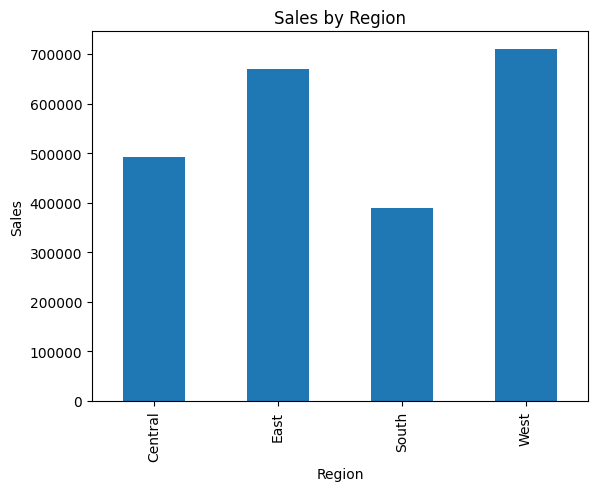

In [8]:
region_sales = df.groupby('Region')['Sales'].sum()

plt.figure()
region_sales.plot(kind='bar')
plt.title('Sales by Region')
plt.ylabel('Sales')
plt.show()

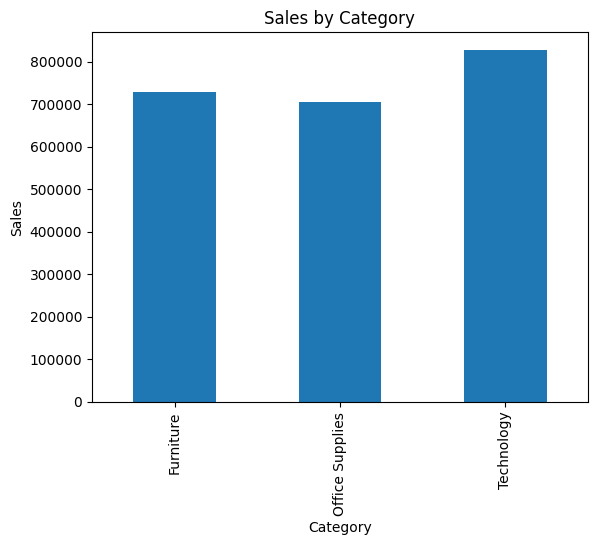

In [9]:
category_sales = df.groupby('Category')['Sales'].sum()

plt.figure()
category_sales.plot(kind='bar')
plt.title('Sales by Category')
plt.ylabel('Sales')
plt.show()

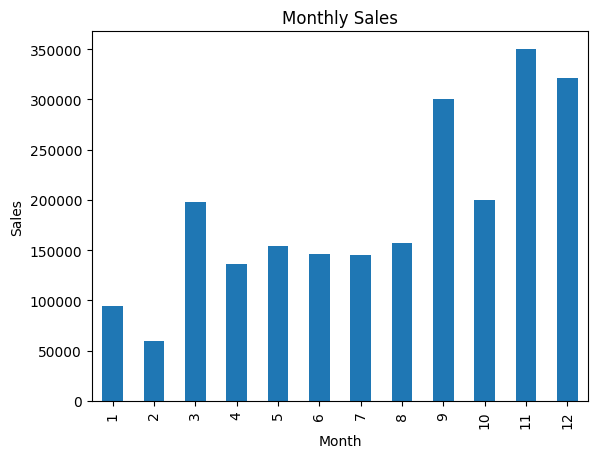

In [10]:
df['Month'] = df['Order Date'].dt.month

monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure()
monthly_sales.plot(kind='bar')
plt.title('Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

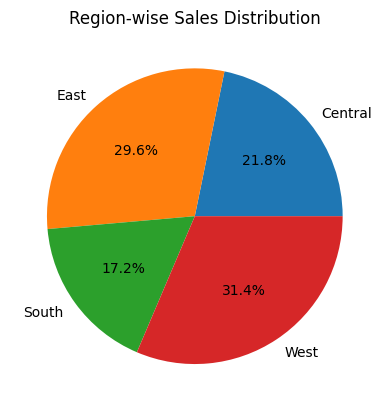

In [11]:
region_sales = df.groupby('Region')['Sales'].sum()

plt.figure()
plt.pie(region_sales, labels=region_sales.index, autopct='%1.1f%%')
plt.title('Region-wise Sales Distribution')
plt.show()

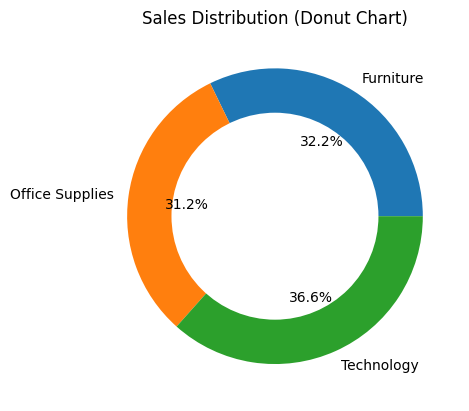

In [12]:
plt.figure()
plt.pie(category_sales, labels=category_sales.index, autopct='%1.1f%%')

# Create donut shape
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Sales Distribution (Donut Chart)')
plt.show()

In [13]:
!pip install folium

In [14]:
import folium
import pandas as pd

In [15]:
state_sales = df.groupby('State')['Sales'].sum().reset_index()

In [16]:
state_coords = {
    'California': [36.77, -119.41],
    'Texas': [31.96, -99.90],
    'New York': [40.71, -74.00],
    'Florida': [27.99, -81.76],
    'Illinois': [40.63, -89.39],
    'Pennsylvania': [41.20, -77.19],
    'Ohio': [40.41, -82.90],
    'Michigan': [44.31, -85.60],
    'Georgia': [32.16, -82.90],
    'North Carolina': [35.75, -79.01]
}

In [17]:
state_sales['lat'] = state_sales['State'].map(lambda x: state_coords.get(x, [None, None])[0])
state_sales['lon'] = state_sales['State'].map(lambda x: state_coords.get(x, [None, None])[1])

state_sales = state_sales.dropna()

In [18]:
m = folium.Map(location=[37, -95], zoom_start=4)

In [22]:
for i in range(len(state_sales)):
    folium.CircleMarker(
        location=[state_sales.iloc[i]['lat'], state_sales.iloc[i]['lon']],
        radius=state_sales.iloc[i]['Sales'] / 50000,  # adjust size
        popup=f"{state_sales.iloc[i]['State']} - Sales: {state_sales.iloc[i]['Sales']}",
        fill=True
    ).add_to(m)

m